
 HARRIS CORNER DETECTION - BUILDING ANALYSIS

Input Image       : Eiffel.jpeg
Image Width       : 427 pixels
Image Height      : 640 pixels
Image Channels    : 3

Image converted to grayscale.

Harris Corner Detection applied.

Harris Parameters:
Block Size       : 2
Kernel Size      : 3
Harris K         : 0.04
Threshold Ratio  : 0.01

Detected Corner Points : 24310
Output saved as       : harris_detected_corners.jpg
Comparison saved as   : harris_comparison.jpg


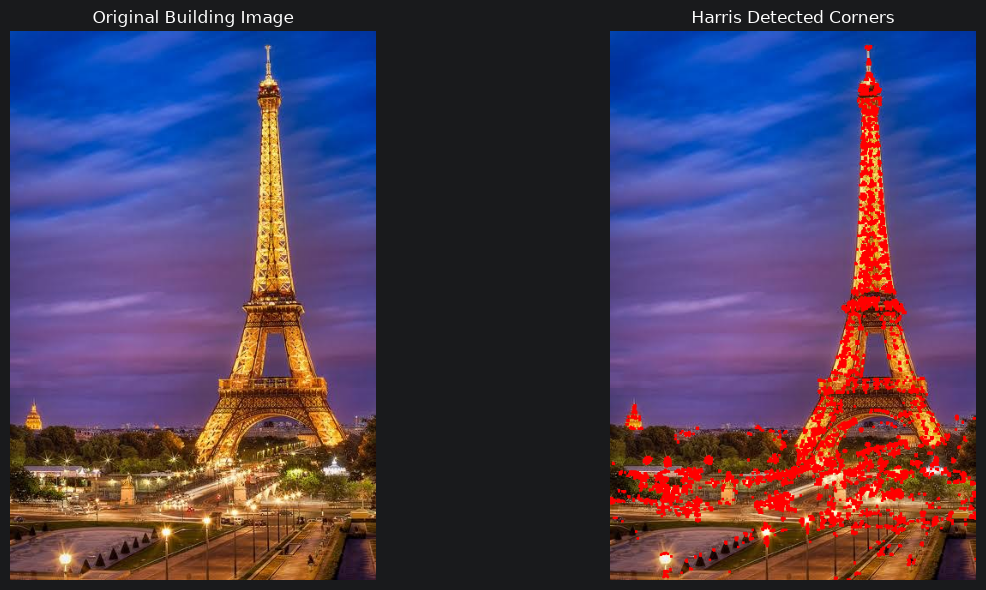

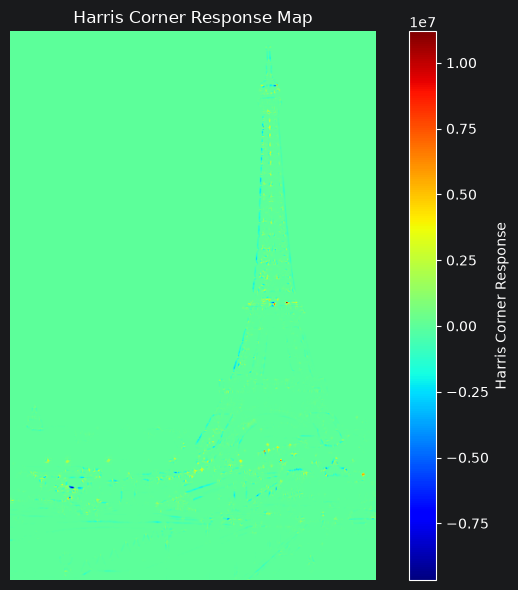


 PROJECT SUMMARY
Algorithm : Harris Corner Detection
Application : Building Feature Detection
Image Size : 427 x 640
Detected Corner Candidates : 24310

Interpretation:
- Strong corner responses represent possible corner points.
- Building structures such as windows, doors,
  roof intersections and wall intersections may produce corners.
- Increasing the threshold gives fewer stronger corners.
- Decreasing the threshold gives more corner candidates.

Project execution completed successfully.


In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

# ============================================================
# HARRIS CORNER DETECTION FOR BUILDING RECOGNITION
# Image Processing - TAE Project
# ============================================================

# -------------------- 1. PROJECT PARAMETERS -----------------

# Input building image
IMAGE_PATH = 'Eiffel.jpeg'

# Harris Corner Detection parameters
BLOCK_SIZE = 2       # Neighborhood size
KERNEL_SIZE = 3      # Sobel aperture size (must be odd)
HARRIS_K = 0.04      # Harris free parameter

# Threshold for selecting strong corners
# Lower value -> more corners
# Higher value -> fewer, stronger corners
THRESHOLD_RATIO = 0.01

# Size of points used for visualization
CORNER_MARK_SIZE = 5

# Apply dilation to make detected corners clearly visible
DILATE_ITERATIONS = 1

# Output file names
OUTPUT_IMAGE = "harris_detected_corners.jpg"
OUTPUT_COMPARISON = "harris_comparison.jpg"


# -------------------- 2. CHECK IMAGE -------------------------

if not os.path.exists(IMAGE_PATH):
    print("ERROR: Image not found!")
    print(f"Please place your building image in the project folder")
    print(f"and name it '{IMAGE_PATH}'.")
    exit()

# Read image
image = cv2.imread(IMAGE_PATH)

if image is None:
    print("ERROR: Could not read the image.")
    exit()

print("\n==============================================")
print(" HARRIS CORNER DETECTION - BUILDING ANALYSIS")
print("==============================================")

print(f"\nInput Image       : {IMAGE_PATH}")
print(f"Image Width       : {image.shape[1]} pixels")
print(f"Image Height      : {image.shape[0]} pixels")
print(f"Image Channels    : {image.shape[2]}")


# -------------------- 3. CONVERT TO GRAYSCALE ---------------

gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

print("\nImage converted to grayscale.")


# -------------------- 4. NOISE REDUCTION ---------------------

# Gaussian blur reduces small unwanted variations
gray_blur = cv2.GaussianBlur(gray, (3, 3), 0)


# -------------------- 5. HARRIS CORNER DETECTION ------------

# Convert grayscale image to float32
gray_float = np.float32(gray_blur)

# Apply Harris Corner Detection
harris_response = cv2.cornerHarris(
    gray_float,
    BLOCK_SIZE,
    KERNEL_SIZE,
    HARRIS_K
)

print("\nHarris Corner Detection applied.")

print("\nHarris Parameters:")
print(f"Block Size       : {BLOCK_SIZE}")
print(f"Kernel Size      : {KERNEL_SIZE}")
print(f"Harris K         : {HARRIS_K}")
print(f"Threshold Ratio  : {THRESHOLD_RATIO}")


# -------------------- 6. DILATE RESPONSE --------------------

# Dilation makes corner regions easier to visualize
harris_dilated = cv2.dilate(
    harris_response,
    None,
    iterations=DILATE_ITERATIONS
)


# -------------------- 7. THRESHOLDING ------------------------

# Calculate threshold from maximum Harris response
threshold = THRESHOLD_RATIO * harris_dilated.max()

# Create a copy for displaying detected corners
result = image.copy()

# Find pixels having strong Harris response
corner_coordinates = np.where(
    harris_dilated > threshold
)

# Count detected pixels/corner candidates
corner_count = len(corner_coordinates[0])


# -------------------- 8. MARK DETECTED CORNERS --------------

# Mark detected corners in the output image
result[
    harris_dilated > threshold
] = [0, 0, 255]     # Red in BGR


# -------------------- 9. SAVE OUTPUT -------------------------

cv2.imwrite(OUTPUT_IMAGE, result)

print(f"\nDetected Corner Points : {corner_count}")
print(f"Output saved as       : {OUTPUT_IMAGE}")


# -------------------- 10. CREATE COMPARISON IMAGE -----------

# Convert images from BGR to RGB for Matplotlib
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
result_rgb = cv2.cvtColor(result, cv2.COLOR_BGR2RGB)

# Create side-by-side comparison
comparison = np.hstack((image_rgb, result_rgb))

# Save comparison image
comparison_bgr = cv2.cvtColor(comparison, cv2.COLOR_RGB2BGR)
cv2.imwrite(OUTPUT_COMPARISON, comparison_bgr)

print(f"Comparison saved as   : {OUTPUT_COMPARISON}")


# -------------------- 11. DISPLAY RESULTS --------------------

plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
plt.imshow(image_rgb)
plt.title("Original Building Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(result_rgb)
plt.title("Harris Detected Corners")
plt.axis("off")

plt.tight_layout()
plt.show()


# -------------------- 12. HARRIS RESPONSE VISUALIZATION -----

plt.figure(figsize=(7, 6))

plt.imshow(harris_response, cmap="jet")
plt.colorbar(label="Harris Corner Response")
plt.title("Harris Corner Response Map")
plt.axis("off")

plt.tight_layout()
plt.show()


# -------------------- 13. PROJECT SUMMARY -------------------

print("\n==============================================")
print(" PROJECT SUMMARY")
print("==============================================")

print("Algorithm : Harris Corner Detection")
print("Application : Building Feature Detection")
print(f"Image Size : {image.shape[1]} x {image.shape[0]}")
print(f"Detected Corner Candidates : {corner_count}")

print("\nInterpretation:")
print("- Strong corner responses represent possible corner points.")
print("- Building structures such as windows, doors,")
print("  roof intersections and wall intersections may produce corners.")
print("- Increasing the threshold gives fewer stronger corners.")
print("- Decreasing the threshold gives more corner candidates.")

print("\nProject execution completed successfully.")